# Revision de APRX con arcpy.mp

Este notebook lista los mapas de un proyecto APRX, permite escoger uno y extrae las rutas/fuentes de datos de todos sus layers.


In [1]:
from datetime import datetime
from pathlib import Path

import arcpy
import pandas as pd

aprx_path = r"\\amssclgis08.ams.gmams.cl\CL_MLP_PAO\01_Proyectos_ArcGIS\APRX\VISOR TERRITORIAL SIG PAO OFFLINE.aprx"

if not Path(aprx_path).exists():
    raise FileNotFoundError(f"No existe el APRX: {aprx_path}")

project = arcpy.mp.ArcGISProject(aprx_path)
project

## 1. Listar mapas del APRX


In [2]:
maps = project.listMaps()

if not maps:
    raise RuntimeError("El APRX no contiene mapas.")

maps_df = pd.DataFrame(
    [{"index": index, "map_name": map_obj.name, "layer_count": len(map_obj.listLayers())} for index, map_obj in enumerate(maps)]
)
maps_df

,index,map_name,layer_count
0,0,MLP SIG PAO INGENIERIA FLUOR,83
1,1,MLP SIG PAO RIESGOS GEOTECNICOS OFFLINE,242
2,2,MLP SIG PAO MEDIDAS OFFLINE,421
3,3,Orto Transversal,5
4,4,MLP SIG PAO MEDIDAS,147
5,5,MLP SIG PAO LAYOUT OFFLINE v4,564
6,6,MLP SIG PAO LAYOUT OFFLINE v5,562
7,7,MLP SIG PAO LAYOUT OFFLINE v6,601


In [3]:
maps_df[maps_df['map_name'] == 'MLP SIG PAO LAYOUT OFFLINE v4']

,index,map_name,layer_count
5,5,MLP SIG PAO LAYOUT OFFLINE v4,564


## 2. Escoger mapa


In [4]:
# Cambia este indice usando la tabla anterior.
selected_map_index = 5

if selected_map_index < 0 or selected_map_index >= len(maps):
    raise IndexError(f"Indice de mapa invalido: {selected_map_index}. Usa un valor entre 0 y {len(maps) - 1}.")

selected_map = maps[selected_map_index]
print(f"Mapa seleccionado: {selected_map.name}")

Mapa seleccionado: MLP SIG PAO LAYOUT OFFLINE v4


## 3. Extraer rutas de layers


In [5]:
def safe_layer_value(layer, attr_name, default=None):
    try:
        return getattr(layer, attr_name)
    except Exception:
        return default


def get_layer_data_source(layer):
    try:
        if layer.supports("DATASOURCE"):
            return layer.dataSource
    except Exception:
        pass
    return None


def get_connection_info(layer):
    try:
        return layer.connectionProperties
    except Exception:
        return None


def layer_has_attachments(layer):
    for value in (layer, get_layer_data_source(layer)):
        if not value:
            continue

        try:
            describe = arcpy.Describe(value)
            has_attachments = getattr(describe, "hasAttachments", None)

            if has_attachments is not None:
                return bool(has_attachments)
        except Exception:
            continue

    return False


def iter_layers_recursive(container, parent_path="", depth=0, seen=None):
    if seen is None:
        seen = set()

    for layer in container.listLayers():
        layer_name = safe_layer_value(layer, "name", "")
        long_name = safe_layer_value(layer, "longName", layer_name)
        layer_path = long_name or (f"{parent_path}\\{layer_name}" if parent_path else layer_name)
        layer_key = layer_path or id(layer)

        if layer_key in seen:
            continue

        seen.add(layer_key)
        yield layer, layer_path, parent_path, depth

        if safe_layer_value(layer, "isGroupLayer", False):
            yield from iter_layers_recursive(layer, layer_path, depth + 1, seen)


layer_rows = []

for order, (layer, layer_path, parent_path, depth) in enumerate(iter_layers_recursive(selected_map), start=1):
    connection_info = get_connection_info(layer)
    layer_rows.append(
        {
            "order": order,
            "map_name": selected_map.name,
            "depth": depth,
            "group_path": parent_path,
            "layer_path": layer_path,
            "layer_name": safe_layer_value(layer, "name"),
            "long_name": safe_layer_value(layer, "longName"),
            "is_group_layer": safe_layer_value(layer, "isGroupLayer", False),
            "is_broken": safe_layer_value(layer, "isBroken", None),
            "visible": safe_layer_value(layer, "visible", None),
            "has_attachments": layer_has_attachments(layer),
            "data_source": get_layer_data_source(layer),
            "connection_info": connection_info,
        }
    )

layers_df = pd.DataFrame(layer_rows)
layers_df.head()

,order,map_name,depth,group_path,layer_path,layer_name,long_name,is_group_layer,is_broken,visible,has_attachments,data_source,connection_info
0,1,MLP SIG PAO LAYOUT OFFLINE v4,0,,SIAS - PAO,SIAS - PAO,SIAS - PAO,False,False,True,False,\\amssclgis08.ams.gmams.cl\CL_MLP_PAO\02_FGDB\...,"{'dataset': 'CL_MLP_PAO_SIAS_PO', 'workspace_f..."
1,2,MLP SIG PAO LAYOUT OFFLINE v4,0,,Cruces,Cruces,Cruces,True,False,False,False,None,None
2,3,MLP SIG PAO LAYOUT OFFLINE v4,1,Cruces,Cruces\Atraviesos Viales FLUOR,Atraviesos Viales FLUOR,Cruces\Atraviesos Viales FLUOR,False,False,True,False,\\amssclgis08.ams.gmams.cl\CL_MLP_PAO\02_FGDB\...,"{'dataset': 'CL_MLP_PAO_Atraviesos_FLUOR_PU', ..."
3,4,MLP SIG PAO LAYOUT OFFLINE v4,1,Cruces,Cruces\Atraviesos Viales Paralelismos,Atraviesos Viales Paralelismos,Cruces\Atraviesos Viales Paralelismos,False,False,True,False,\\amssclgis08.ams.gmams.cl\CL_MLP_PAO\02_FGDB\...,"{'dataset': 'CL_MLP_PAO_Atraviesos_FLUOR_PO', ..."
4,5,MLP SIG PAO LAYOUT OFFLINE v4,1,Cruces,Cruces\Cruces Ferronor,Cruces Ferronor,Cruces\Cruces Ferronor,False,False,True,False,\\amssclgis08.ams.gmams.cl\CL_MLP_PAO\02_FGDB\...,{'dataset': 'CL_MLP_PAO_OBRAS_PUNTUALES_EIA_PU...


## 4. Ver solo layers con ruta/fuente de datos


In [6]:
layers_with_sources_df = layers_df[layers_df["data_source"].notna()].copy()
layers_with_sources_df[["order", "depth", "group_path", "layer_path", "is_broken", "has_attachments", "data_source"]]

,order,depth,group_path,layer_path,is_broken,has_attachments,data_source
0,1,0,,SIAS - PAO,False,False,\\amssclgis08.ams.gmams.cl\CL_MLP_PAO\02_FGDB\...
2,3,1,Cruces,Cruces\Atraviesos Viales FLUOR,False,False,\\amssclgis08.ams.gmams.cl\CL_MLP_PAO\02_FGDB\...
3,4,1,Cruces,Cruces\Atraviesos Viales Paralelismos,False,False,\\amssclgis08.ams.gmams.cl\CL_MLP_PAO\02_FGDB\...
4,5,1,Cruces,Cruces\Cruces Ferronor,False,False,\\amssclgis08.ams.gmams.cl\CL_MLP_PAO\02_FGDB\...
6,7,1,Permisos,Permisos\PS 51 Permisos Vialidad,False,False,\\amssclgis08.ams.gmams.cl\CL_MLP_PAO\02_FGDB\...
...,...,...,...,...,...,...,...
556,557,1,Monitoreo Social Territorial,Monitoreo Social Territorial\Monitoreo Predios,False,False,\\amssclgis08.ams.gmams.cl\CL_MLP_PAO\02_FGDB\...
558,559,1,Trazas Tranque Mauro,Trazas Tranque Mauro\Trazas Tranque - Lineas,False,False,\\amssclgis08.ams.gmams.cl\CL_MLP_PAO\02_FGDB\...
559,560,1,Trazas Tranque Mauro,Trazas Tranque Mauro\Trazas Tranque - Polígono,False,False,\\amssclgis08.ams.gmams.cl\CL_MLP_PAO\02_FGDB\...
562,563,2,Mapa Base\Mapa Base,Mapa Base\Mapa Base\World Imagery Chacay,False,False,\\amssclgis08.ams.gmams.cl\CL_MLP_PAO\05_Image...


## 5. Listar layers con attachments


In [7]:
layers_with_attachments_df = layers_df[layers_df["has_attachments"] == True].copy()

attachment_columns = [
    "order",
    "depth",
    "group_path",
    "layer_path",
    "layer_name",
    "is_broken",
    "data_source",
]

layers_with_attachments_df[attachment_columns]

,order,depth,group_path,layer_path,layer_name,is_broken,data_source


## 6. Exportar resultado a CSV


In [8]:
safe_map_name = "".join(char if char.isalnum() or char in "-_" else "_" for char in selected_map.name)
output_csv = Path.cwd() / f"layers_{safe_map_name}.csv"
attachments_csv = Path.cwd() / f"layers_with_attachments_{safe_map_name}.csv"

layers_with_sources_df.to_csv(output_csv, index=False, encoding="utf-8-sig")
layers_with_attachments_df.to_csv(attachments_csv, index=False, encoding="utf-8-sig")

output_csv, attachments_csv

(WindowsPath('c:/Users/esrlrivero_adm/Documents/Geosupport/amsa-pao-geosupport/layers_MLP_SIG_PAO_LAYOUT_OFFLINE_v4.csv'),
 WindowsPath('c:/Users/esrlrivero_adm/Documents/Geosupport/amsa-pao-geosupport/layers_with_attachments_MLP_SIG_PAO_LAYOUT_OFFLINE_v4.csv'))

## 7. Crear Mobile Map Package del mapa seleccionado


In [10]:
def sanitize_filename(value):
    return "".join(char if char.isalnum() or char in "-_" else "_" for char in value).strip("_")


arcpy.env.overwriteOutput = True

mmpk_dir = Path.cwd() / "mmpk"
mmpk_dir.mkdir(parents=True, exist_ok=True)

mmpk_name = f"{sanitize_filename(selected_map.name)}.mmpk"
mmpk_path = mmpk_dir / mmpk_name

if mmpk_path.exists():
    mmpk_path.unlink()

package_generated_at = pd.Timestamp.now(tz="America/Santiago")
package_generated_at_text = package_generated_at.strftime("%Y-%m-%d %H:%M:%S %Z")

mmpk_title = selected_map.name
mmpk_summary = (
    f"Mobile Map Package del mapa '{selected_map.name}', generado desde el proyecto "
    f"{Path(aprx_path).name} el {package_generated_at_text}."
)
mmpk_tags = "PAO, GeoSupport, MMPK, ArcGIS Pro"

result = arcpy.management.CreateMobileMapPackage(
    selected_map,
    str(mmpk_path),
    title=mmpk_title,
    summary=mmpk_summary,
    tags=mmpk_tags,
    anonymous_use="ANONYMOUS_USE",
)

print(arcpy.GetMessages())
print(f"MMPK creado: {mmpk_path}")
mmpk_path

Start Time: viernes, 19 de junio de 2026 11:16:57
Succeeded at viernes, 19 de junio de 2026 12:22:17 (Elapsed Time: 1 hours 5 minutes 19 seconds)
MMPK creado: c:\Users\esrlrivero_adm\Documents\Geosupport\amsa-pao-geosupport\mmpk\MLP_SIG_PAO_LAYOUT_OFFLINE_v4.mmpk


WindowsPath('c:/Users/esrlrivero_adm/Documents/Geosupport/amsa-pao-geosupport/mmpk/MLP_SIG_PAO_LAYOUT_OFFLINE_v4.mmpk')

## 8. Actualizar item MMPK existente en Portal


Item actualizado: True
https://sig.aminerals.cl/portal//home/item.html?id=108e95e1d79d4935a93bbea3db536d59


<Item title:"CL MLP PAO - LAYOUT OFFLINE 19-06-2026" type:Mobile Map Package owner:admmlppao>
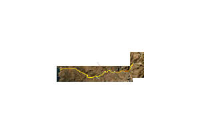

In [11]:
from arcgis.gis import GIS
import json
from datetime import datetime
import re
cred = json.load(open('./Json/AMSA.json'))['PAO']

# Completa el ID del item Mobile Map Package existente en Portal/ArcGIS Online.
portal_mmpk_item_id = "108e95e1d79d4935a93bbea3db536d59"

if not portal_mmpk_item_id:
    raise ValueError("Completa portal_mmpk_item_id con el ID del item MMPK que se debe actualizar.")

if not mmpk_path.exists():
    raise FileNotFoundError(f"No existe el MMPK local: {mmpk_path}")


# Usa la sesion activa de ArcGIS Pro. Si no funciona, reemplaza por:
gis = GIS(cred['url'], cred['user'], cred["pass"])

mmpk_item = gis.content.get(portal_mmpk_item_id)

if mmpk_item is None:
    raise ValueError(f"No se encontro el item en Portal: {portal_mmpk_item_id}")


update_timestamp = pd.Timestamp.now(tz="America/Santiago")
# update_timestamp = datetime.now().astimezone()
update_timestamp_text = update_timestamp.strftime("%Y-%m-%d %H:%M:%S %Z")
source_aprx_name = Path(aprx_path).name
source_aprx_path = str(Path(aprx_path))

fecha_nueva = update_timestamp.strftime("%d-%m-%Y")
title_actual = mmpk_item.title
# Reemplazar fecha al final del título
title_nuevo = re.sub(
    r"\d{2}-\d{2}-\d{4}$",
    fecha_nueva,
    title_actual
)


portal_snippet = (
    f"MMPK actualizado el {update_timestamp_text}."
)

portal_description = f"""
<p><strong>Mobile Map Package actualizado para uso offline del proyecto PAO.</strong></p>
<p>Este item fue actualizado mediante el flujo automatizado de GeoSupport usando ArcGIS Pro y ArcGIS API for Python.</p>
<ul>
  <li><strong>Fecha de actualizacion:</strong> {update_timestamp_text}</li>
  <li><strong>Mapa publicado:</strong> {selected_map.name}</li>
  <li><strong>Proyecto APRX origen:</strong> {source_aprx_name}</li>
  <li><strong>Archivo MMPK generado:</strong> {mmpk_path.name}</li>
</ul>
<p>La actualizacion reemplaza el archivo del item existente manteniendo su identificador en Portal.</p>
""".strip()

updated = mmpk_item.update(
    item_properties={
        "title": title_nuevo,
        "snippet": portal_snippet,
        "description": portal_description,
        "tags": mmpk_tags,
    },
    data=str(mmpk_path),
    
)

print(f"Item actualizado: {updated}")
print(mmpk_item.homepage)
mmpk_item